In [1]:
#1. Problem statement
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
#2. Data Loading
df = pd.read_csv("netflix_titles.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24

In [3]:
#3.Data Understanding
df['director']= df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year

df.dropna(subset=['type'], inplace=True)

print("\nCleaned Data:")
print(df.head())


Cleaned Data:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added  release_year rating   duration  \
0 2021-09-25          2020  PG-13     90 min   
1 2021-09-24          2021  TV-MA  2 Seasons   
2 2021-09-24          2021  TV-MA   1 Sea

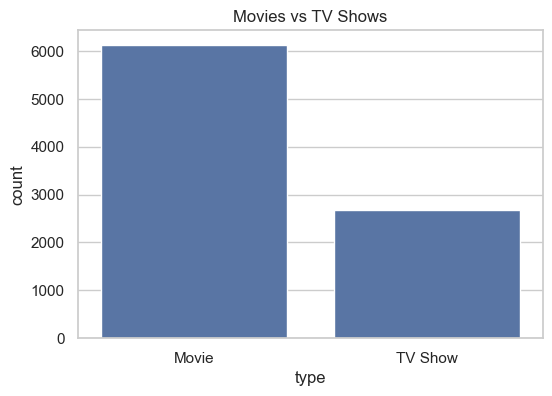

In [4]:
#4.Data cleaning and Preprocessing
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

In [ ]:
#5.Exploratory Data Analysis
plt.figure(figsize=(10,5))
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()


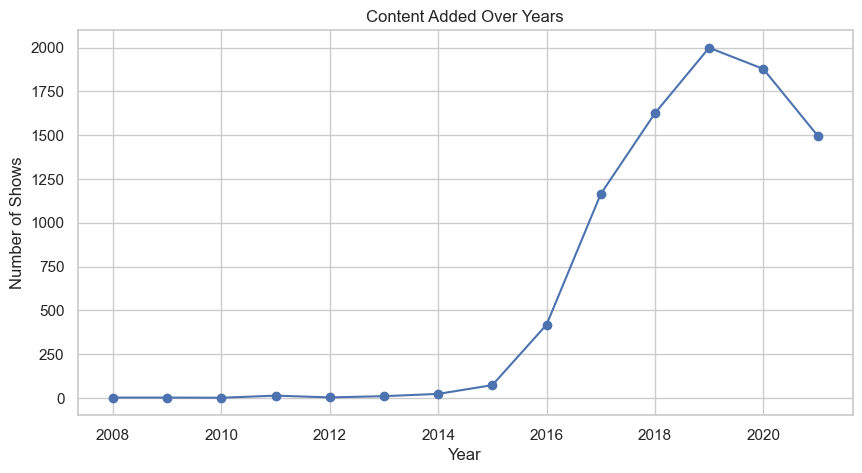

In [6]:
#6.Data Visualization
plt.figure(figsize=(10,5))
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Shows")
plt.show()


In this section, various visualizations were created to better understand the dataset and uncover patterns. Graphs such as count plots, bar charts, and line plots were used to analyze the distribution of Movies and TV Shows, top content-producing countries, content growth over the years, and popular genres. These visualizations help in identifying trends and making the data more interpretable.

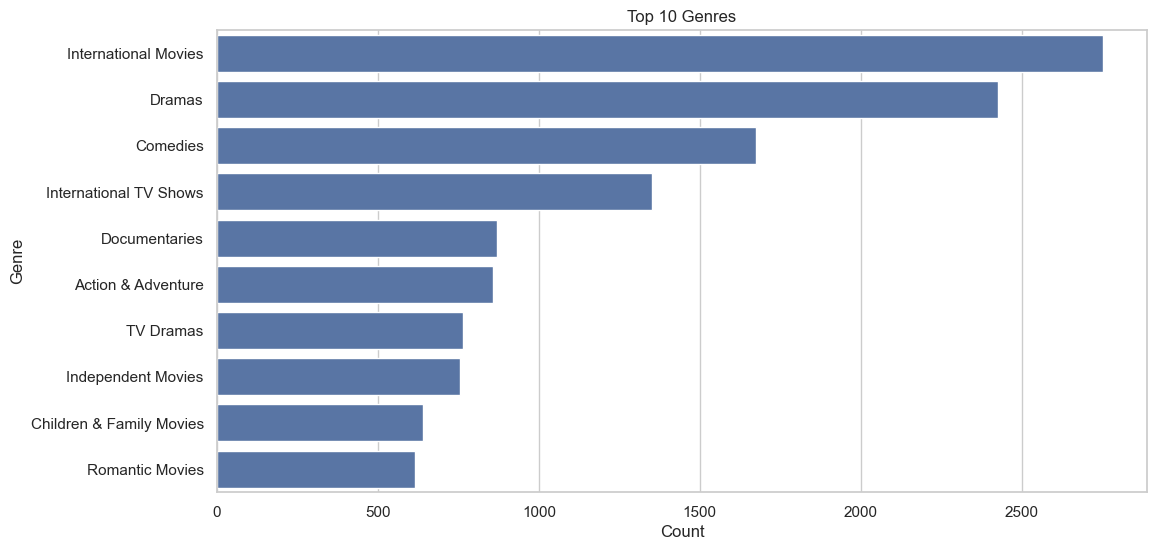

In [7]:
#7.Insights
plt.figure(figsize=(12,6))
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

From the analysis, several key insights were observed. The dataset shows that Movies are more dominant on Netflix compared to TV Shows. The United States is the leading contributor of content on the platform. A significant increase in content addition is observed after 2018, indicating rapid platform growth. Additionally, genres like Drama and Comedy are the most popular among users.

In [8]:
#8.Conclusion
print("\n===== INSIGHTS =====")

print("Most content type:")
print(df['type'].value_counts())

print("\nTop country:")
print(df['country'].value_counts().head(1))

print("\nTop genre:")
print(genres.value_counts().head(1))

print("\nYear with most releases:")
print(df['year_added'].value_counts().head(1))


===== INSIGHTS =====
Most content type:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Top country:
country
United States    2818
Name: count, dtype: int64

Top genre:
listed_in
International Movies    2752
Name: count, dtype: int64

Year with most releases:
year_added
2019.0    1999
Name: count, dtype: int64


In conclusion, the Netflix dataset analysis provided meaningful insights into content distribution, growth trends, and user preferences. The use of data cleaning, analysis, and visualization techniques helped in extracting valuable information from the dataset. This project demonstrates how exploratory data analysis can be used to understand real-world datasets and support data-driven decision-making.